In [1]:
# ============================================================
# STUDENT CHURN PREDICTION USING MACHINE LEARNING
# END-TO-END DATA ANALYSIS PROJECT
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

print("Libraries Imported Successfully")


Libraries Imported Successfully


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

FILE = r"C:\Users\karim\Downloads\sample_student_churn_dataset.csv"

df = pd.read_csv(FILE)

print("\nDataset Loaded Successfully")
print("Dataset Shape:", df.shape)

display(df.head())


Dataset Loaded Successfully
Dataset Shape: (120, 10)


,Age,Gender_enc,Country,Current_Major,Opportunity_Duration,Apply_Lead_Days,Signup_Year,Signup_Month,engagement_score,churn
0,20,0,India,Cyber Security,84,39,2024,11,4.96,0
1,21,0,Nigeria,Information Systems,87,37,2024,5,2.42,0
2,33,0,United States,Computer Science,76,17,2024,6,5.19,0
3,32,1,Nigeria,Cyber Security,67,74,2024,9,12.49,0
4,31,1,Nigeria,Business Analytics,63,6,2024,10,10.47,1


In [3]:

# ============================================================
# 3. DATA UNDERSTANDING
# ============================================================

print("\nDataset Information")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nSummary Statistics")
display(df.describe())




Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   120 non-null    int64  
 1   Gender_enc            120 non-null    int64  
 2   Country               120 non-null    object 
 3   Current_Major         120 non-null    object 
 4   Opportunity_Duration  120 non-null    int64  
 5   Apply_Lead_Days       120 non-null    int64  
 6   Signup_Year           120 non-null    int64  
 7   Signup_Month          120 non-null    int64  
 8   engagement_score      120 non-null    float64
 9   churn                 120 non-null    int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 9.5+ KB

Missing Values
Age                     0
Gender_enc              0
Country                 0
Current_Major           0
Opportunity_Duration    0
Apply_Lead_Days         0
Signup_Year             0
Si

,Age,Gender_enc,Opportunity_Duration,Apply_Lead_Days,Signup_Year,Signup_Month,engagement_score,churn
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,26.016667,0.533333,66.025000,47.025000,2024.858333,7.183333,8.380917,0.216667
std,5.149828,0.500979,30.679274,26.291981,0.713564,3.353121,3.822792,0.413701
min,18.000000,0.000000,9.000000,0.000000,2024.000000,1.000000,1.070000,0.000000
25%,21.000000,0.000000,41.750000,22.750000,2024.000000,4.000000,5.547500,0.000000
50%,26.000000,1.000000,69.000000,48.500000,2025.000000,7.000000,8.455000,0.000000
75%,30.000000,1.000000,87.000000,70.250000,2025.000000,10.000000,11.507500,0.000000
max,35.000000,1.000000,120.000000,90.000000,2026.000000,12.000000,14.970000,1.000000


In [4]:
# ============================================================
# 4. DATA CLEANING
# ============================================================

# Check duplicates
duplicates = df.duplicated().sum()

print("\nDuplicate Rows:", duplicates)

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates Removed")




Duplicate Rows: 0


In [5]:

# ============================================================
# 5. HANDLE MISSING VALUES
# ============================================================

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include="object").columns

# Fill numeric columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Cleaning")
print(df.isnull().sum())


Missing Values After Cleaning
Age                     0
Gender_enc              0
Country                 0
Current_Major           0
Opportunity_Duration    0
Apply_Lead_Days         0
Signup_Year             0
Signup_Month            0
engagement_score        0
churn                   0
dtype: int64


In [6]:
# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

# High engagement feature
df["High_Engagement"] = np.where(
    df["engagement_score"] >= 8,
    1,
    0
)

# Long duration feature
df["Long_Duration"] = np.where(
    df["Opportunity_Duration"] > 60,
    1,
    0
)

print("\nFeature Engineering Completed")



Feature Engineering Completed


In [7]:

# ============================================================
# 7. ENCODING CATEGORICAL VARIABLES
# ============================================================

label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("\nEncoding Completed")

display(df.head())



Encoding Completed


,Age,Gender_enc,Country,Current_Major,Opportunity_Duration,Apply_Lead_Days,Signup_Year,Signup_Month,engagement_score,churn,High_Engagement,Long_Duration
0,20,0,2,2,84,39,2024,11,4.96,0,0,1
1,21,0,3,4,87,37,2024,5,2.42,0,0,1
2,33,0,4,1,76,17,2024,6,5.19,0,0,1
3,32,1,3,2,67,74,2024,9,12.49,0,1,1
4,31,1,3,0,63,6,2024,10,10.47,1,1,1


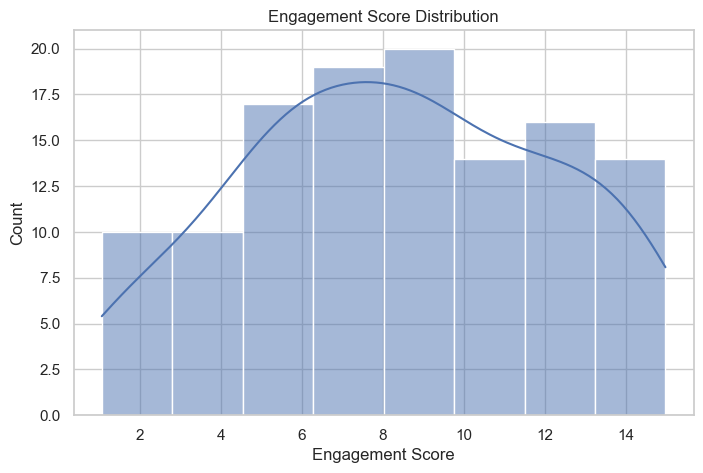

In [8]:

# ============================================================
# 8. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

sns.set(style="whitegrid")


# ------------------------------------------------------------
# Engagement Score Distribution
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(df["engagement_score"], kde=True)

plt.title("Engagement Score Distribution")
plt.xlabel("Engagement Score")
plt.ylabel("Count")

plt.show()


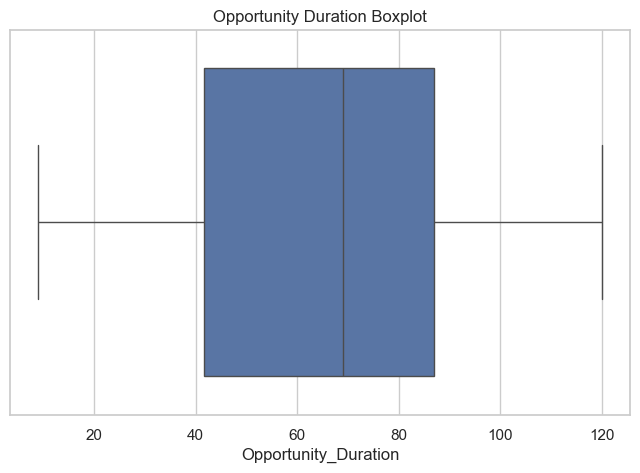

In [9]:

# ------------------------------------------------------------
# Opportunity Duration Boxplot
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(x=df["Opportunity_Duration"])

plt.title("Opportunity Duration Boxplot")

plt.show()



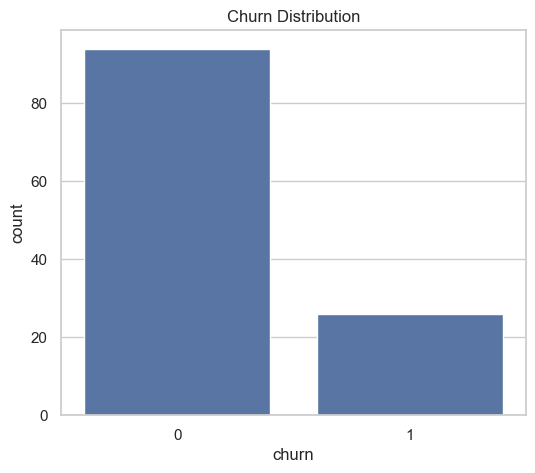

In [10]:

# ------------------------------------------------------------
# Churn Distribution
# ------------------------------------------------------------

plt.figure(figsize=(6,5))

sns.countplot(x=df["churn"])

plt.title("Churn Distribution")

plt.show()

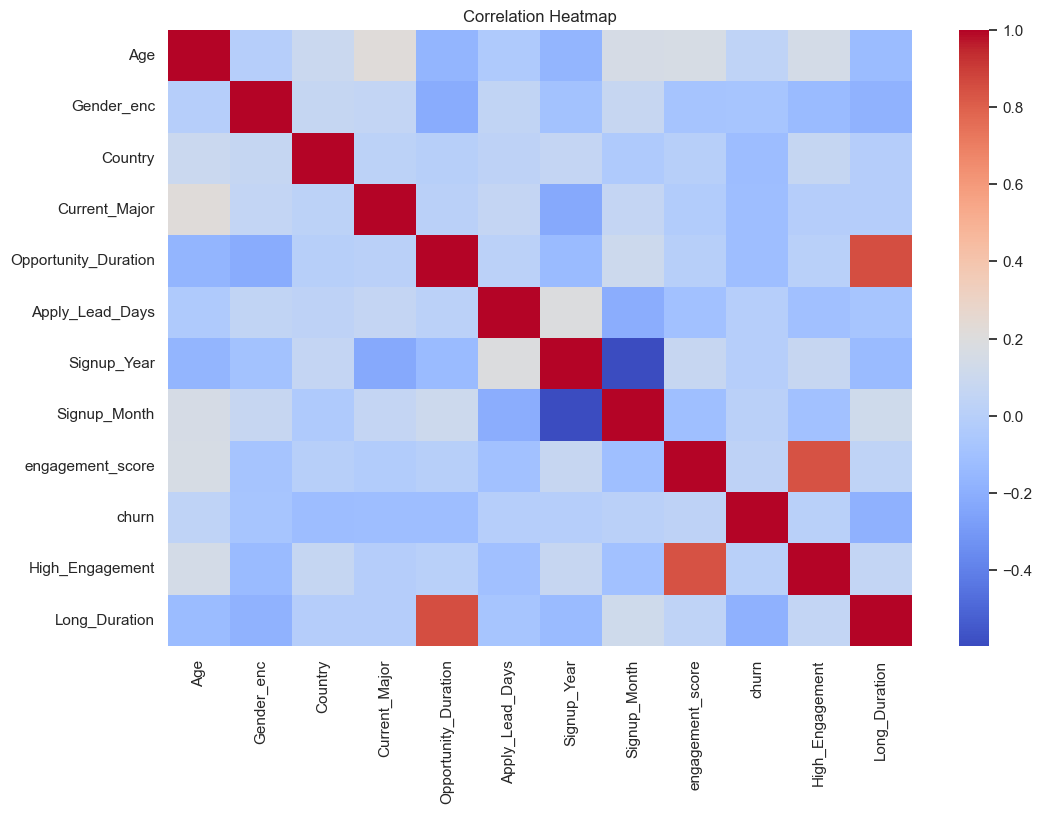

In [11]:

# ------------------------------------------------------------
# Correlation Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()




In [12]:


# ============================================================
# 9. FEATURE SELECTION
# ============================================================

target = "churn"

X = df.drop(target, axis=1)
y = df[target]

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)





Features Shape: (120, 11)
Target Shape: (120,)


In [13]:


# ============================================================
# 10. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain-Test Split Completed")

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))




Train-Test Split Completed
Training Samples: 96
Testing Samples: 24


In [14]:

# ============================================================
# 11. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature Scaling Completed")




Feature Scaling Completed


In [15]:

# ============================================================
# 12. LOGISTIC REGRESSION MODEL
# ============================================================

lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("\n================ LOGISTIC REGRESSION ================\n")

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1 Score:",
      f1_score(y_test, lr_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, lr_pred))




================ LOGISTIC REGRESSION ================

Accuracy: 0.7916666666666666
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.5


In [16]:


# ============================================================
# 13. DECISION TREE MODEL
# ============================================================

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("\n================ DECISION TREE ================\n")

print("Accuracy:",
      accuracy_score(y_test, dt_pred))

print("Precision:",
      precision_score(y_test, dt_pred))

print("Recall:",
      recall_score(y_test, dt_pred))

print("F1 Score:",
      f1_score(y_test, dt_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, dt_pred))




================ DECISION TREE ================

Accuracy: 0.7083333333333334
Precision: 0.25
Recall: 0.2
F1 Score: 0.2222222222222222
ROC-AUC: 0.5210526315789473


In [17]:

# ============================================================
# 14. RANDOM FOREST MODEL
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\n================ RANDOM FOREST ================\n")

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, rf_pred))



================ RANDOM FOREST ================

Accuracy: 0.75
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.4736842105263158


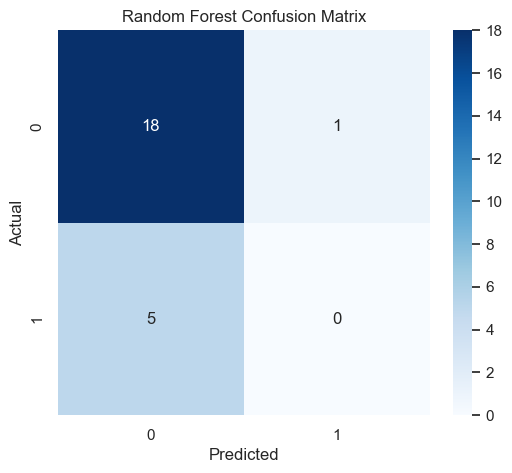

In [18]:

# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()




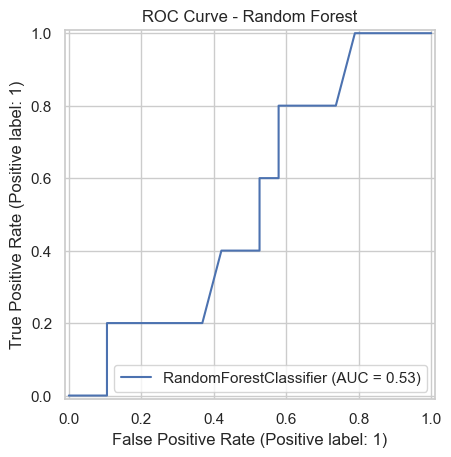

In [19]:

# ============================================================
# 16. ROC CURVE
# ============================================================

RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")

plt.show()



Top 10 Important Features


,Feature,Importance
4,Opportunity_Duration,0.160489
5,Apply_Lead_Days,0.148773
8,engagement_score,0.139949
7,Signup_Month,0.127034
0,Age,0.104353
2,Country,0.092724
3,Current_Major,0.088851
6,Signup_Year,0.059450
1,Gender_enc,0.032535
10,Long_Duration,0.025368


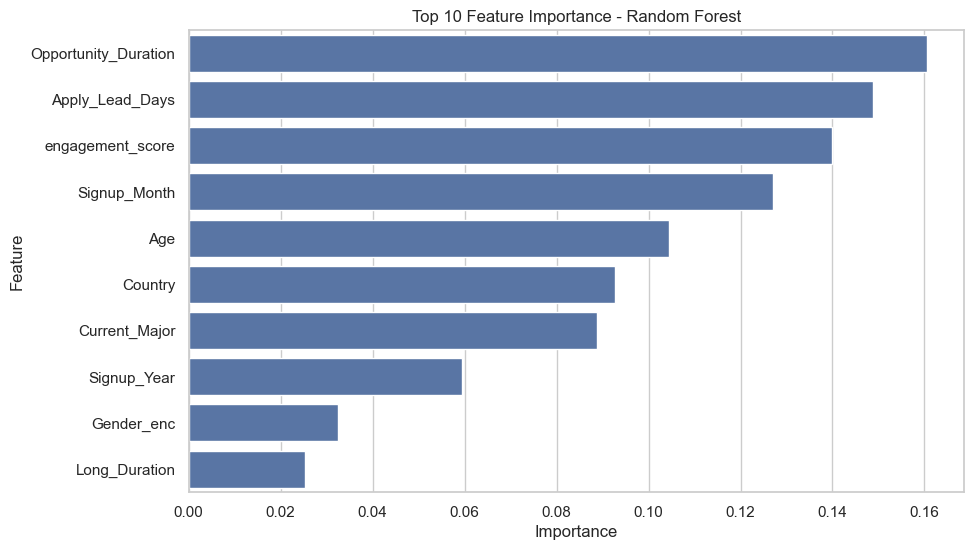

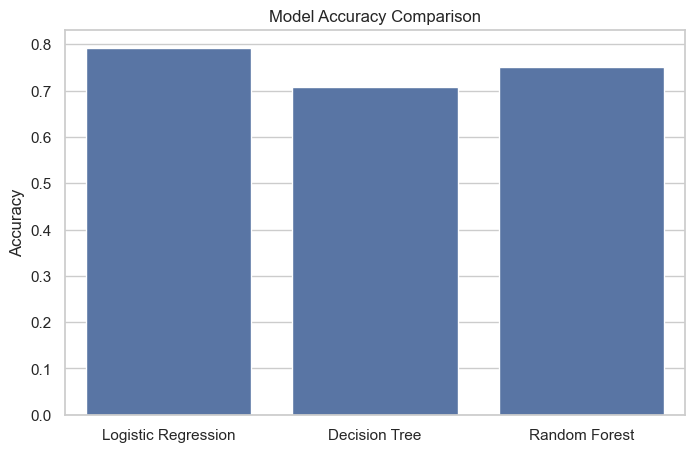

In [20]:


# ============================================================
# 17. FEATURE IMPORTANCE
# ============================================================

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features")

display(feature_importance.head(10))


plt.figure(figsize=(10,6))

sns.barplot(
    x=feature_importance.head(10)["Importance"],
    y=feature_importance.head(10)["Feature"]
)

plt.title("Top 10 Feature Importance - Random Forest")

plt.show()


# ============================================================
# 18. MODEL COMPARISON
# ============================================================

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

plt.figure(figsize=(8,5))

sns.barplot(
    x=models,
    y=accuracies
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()




In [21]:

# ============================================================
# 19. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report - Random Forest\n")

print(classification_report(y_test, rf_pred))




Classification Report - Random Forest

              precision    recall  f1-score   support

           0       0.78      0.95      0.86        19
           1       0.00      0.00      0.00         5

    accuracy                           0.75        24
   macro avg       0.39      0.47      0.43        24
weighted avg       0.62      0.75      0.68        24



In [22]:

# ============================================================
# 20. FINAL INSIGHTS
# ============================================================

print("\n================ FINAL INSIGHTS ================\n")

print("1. Random Forest achieved the best performance.")
print("2. Engagement Score strongly influences churn.")
print("3. Long duration opportunities increase dropout risk.")
print("4. Signup timing patterns affect learner retention.")
print("5. Early identification of at-risk learners can improve completion rates.")





================ FINAL INSIGHTS ================

1. Random Forest achieved the best performance.
2. Engagement Score strongly influences churn.
3. Long duration opportunities increase dropout risk.
4. Signup timing patterns affect learner retention.
5. Early identification of at-risk learners can improve completion rates.


In [23]:

# ============================================================
# 21. CONCLUSION
# ============================================================

print("\n================ CONCLUSION ================\n")

print("""
This project successfully analyzed learner behavior
and predicted churn using machine learning models.

Random Forest performed best among all models and
can be used for early intervention and retention strategies.
""")



================ CONCLUSION ================


This project successfully analyzed learner behavior
and predicted churn using machine learning models.

Random Forest performed best among all models and
can be used for early intervention and retention strategies.



In [24]:


# ============================================================
# 22. SAVE CLEANED DATASET
# ============================================================

df.to_csv(
    "cleaned_student_churn_dataset.csv",
    index=False
)

print("\nCleaned Dataset Saved Successfully")


Cleaned Dataset Saved Successfully
